# LeetCode #65: Valid Number

https://leetcode.com/problems/valid-number/

## Comparison of Approaches

| Approach | Time | Space |
| :--- | :--- | :--- |
| **Regex** | $O(n)$ | $O(1)$ |
| **State Machine** | $O(n)$ | $O(1)$ |
| **Rule-Based Scan** ★ | $O(n)$ | $O(1)$ |

---

## Understanding the Methods

### Regex
Build a regex pattern for the grammar. Works but hard to reason about and language-specific.

### State Machine
Define states (integer, decimal, exponent, etc.) and valid transitions. Formal but verbose.

### Optimal: Rule-Based Scan ★
Track four boolean flags: `seenDigit`, `seenDot`, `seenExp`, and whether digits appeared after the exponent (by resetting `seenDigit = false` at `e/E`). Apply per-character rules:
- Digit: set `seenDigit = true`
- Sign `+/-`: valid only at i=0 or immediately after `e/E`
- Dot `.`: valid only if no dot seen yet and no exponent yet
- `e/E`: valid only if no exponent yet and at least one digit before it; then reset `seenDigit = false` to require digits after
- Anything else: return false

Final check: `seenDigit` must be true (handles `"e"`, `"+"`, `"."` edge cases).

**Constraints:**
* $1 \leq$ s.length $\leq 20$
* s consists of only English letters, digits, `'+'`, `'-'`, or `'.'`

## Solutions

### C#

In [ ]:
public class Solution {
    public bool IsNumber(string s) {
        bool seenDigit = false, seenDot = false, seenExp = false;
        for (int i = 0; i < s.Length; i++) {
            char c = s[i];
            if (char.IsDigit(c)) {
                seenDigit = true;
            } else if (c == '+' || c == '-') {
                if (i > 0 && s[i-1] != 'e' && s[i-1] != 'E') return false;
            } else if (c == '.') {
                if (seenDot || seenExp) return false;
                seenDot = true;
            } else if (c == 'e' || c == 'E') {
                if (seenExp || !seenDigit) return false;
                seenExp = true;
                seenDigit = false; // require digits after e/E
            } else {
                return false;
            }
        }
        return seenDigit;
    }
}

### Python

In [ ]:
class Solution:
    def isNumber(self, s: str) -> bool:
        seen_digit = seen_dot = seen_exp = False
        for i, c in enumerate(s):
            if c.isdigit():
                seen_digit = True
            elif c in '+-':
                if i > 0 and s[i-1] not in 'eE':
                    return False
            elif c == '.':
                if seen_dot or seen_exp:
                    return False
                seen_dot = True
            elif c in 'eE':
                if seen_exp or not seen_digit:
                    return False
                seen_exp = True
                seen_digit = False
            else:
                return False
        return seen_digit

### Go

In [ ]:
package main

func isNumber(s string) bool {
	seenDigit, seenDot, seenExp := false, false, false
	for i := 0; i < len(s); i++ {
		c := s[i]
		switch {
		case c >= '0' && c <= '9':
			seenDigit = true
		case c == '+' || c == '-':
			if i > 0 && s[i-1] != 'e' && s[i-1] != 'E' {
				return false
			}
		case c == '.':
			if seenDot || seenExp {
				return false
			}
			seenDot = true
		case c == 'e' || c == 'E':
			if seenExp || !seenDigit {
				return false
			}
			seenExp = true
			seenDigit = false
		default:
			return false
		}
	}
	return seenDigit
}

### Rust

In [ ]:
pub struct Solution;

impl Solution {
    pub fn is_number(s: String) -> bool {
        let bytes = s.as_bytes();
        let (mut seen_digit, mut seen_dot, mut seen_exp) = (false, false, false);
        for (i, &c) in bytes.iter().enumerate() {
            match c {
                b'0'..=b'9' => seen_digit = true,
                b'+' | b'-' => {
                    if i > 0 && bytes[i-1] != b'e' && bytes[i-1] != b'E' {
                        return false;
                    }
                }
                b'.' => {
                    if seen_dot || seen_exp { return false; }
                    seen_dot = true;
                }
                b'e' | b'E' => {
                    if seen_exp || !seen_digit { return false; }
                    seen_exp = true;
                    seen_digit = false;
                }
                _ => return false,
            }
        }
        seen_digit
    }
}

## Example Scenarios

### 1. Common Case — Simple Decimal
**Input:** `s = "-3.14"`

Walk through: '-' at i=0 → valid sign. '3' → seenDigit=true. '.' → seenDot=true (no dot or exp seen yet). '1','4' → digits. End: seenDigit=true → return `true`. Standard decimal with leading sign.

**Why tricky:** Walks through all rules without triggering rejection. Interviewers use this to confirm you can articulate the flag-based approach before edge cases.

### 2. Slightly Complex — Full Format: Sign, Dot, Exponent, Sign
**Input:** `s = "+.8e-12"`

Walk through: '+' at i=0 → valid. '.' → seenDot=true (no exp yet). '8' → seenDigit=true. 'e' → seenExp=true, seenDigit reset to false (need digits after e). '-' right after e → valid sign. '1','2' → seenDigit=true. End: seenDigit=true → `true`. Represents $0.8 \times 10^{-12}$.

**Why tricky:** Tests every feature at once: leading sign, leading dot with no integer part, exponent with sign. The key insight: "." before digits is fine IF digits follow. The seenDigit reset after 'e' enforces "digits required after exponent." Interviewers use this to test thoroughness.

### 3. Edge Case: Time Factor — Maximum Length String (20 chars)
**Input:** `s = "-99999999999999999e2"` (20 characters)

Walk through: Sign, 17 digits, 'e', 1 digit. All pass rules. Total: 20 iterations, $O(n)$ time. This problem is always $O(n)$ regardless of approach (regex, state machine, rule-based), so time is not a differentiator.

**Why tricky:** With max length = 20, performance is not the challenge — correctness is. Interviewers focus entirely on whether your validation handles all valid/invalid patterns. Candidates should still state: "$O(n)$ time, $O(1)$ space, single pass."

### 4. Edge Case: Space Factor — Double Exponent Rejection
**Input:** `s = "1e1e1"`

Walk through: '1' → seenDigit=true. 'e' → seenExp=true, seenDigit=false. '1' → seenDigit=true. Second 'e' → seenExp already true → return `false`. The rule-based approach uses only 3 boolean flags ($O(1)$ space).

**Why tricky:** A state machine approach may define 8+ explicit states, but both are $O(1)$ space. The rule-based scan is simpler to implement and debug. Interviewers test double-exponent to verify the seenExp flag is checked correctly.

### 5. Almost-Impossible but Plausible — Near-Miss Decoys
**Input:** `"."` | `"e"` | `"+E"` | `".e1"` | `"6e6.5"`

Walk through: `"."` → seenDigit=false at end → false. `"e"` → 'e' requires seenDigit=true before it → false. `"+E"` → same as "e" with sign → false. `".e1"` → dot sets seenDot, but seenDigit still false when 'e' appears → false. `"6e6.5"` → dot after exponent blocked by seenExp=true → false.

**Why tricky:** Each string appears almost valid but violates exactly one constraint. These are the hardest test cases — they test every branch of validation logic. Interviewers use these to verify complete coverage of the rule set. The `".e1"` case is especially tricky: a dot alone doesn't count as "digits seen."

---

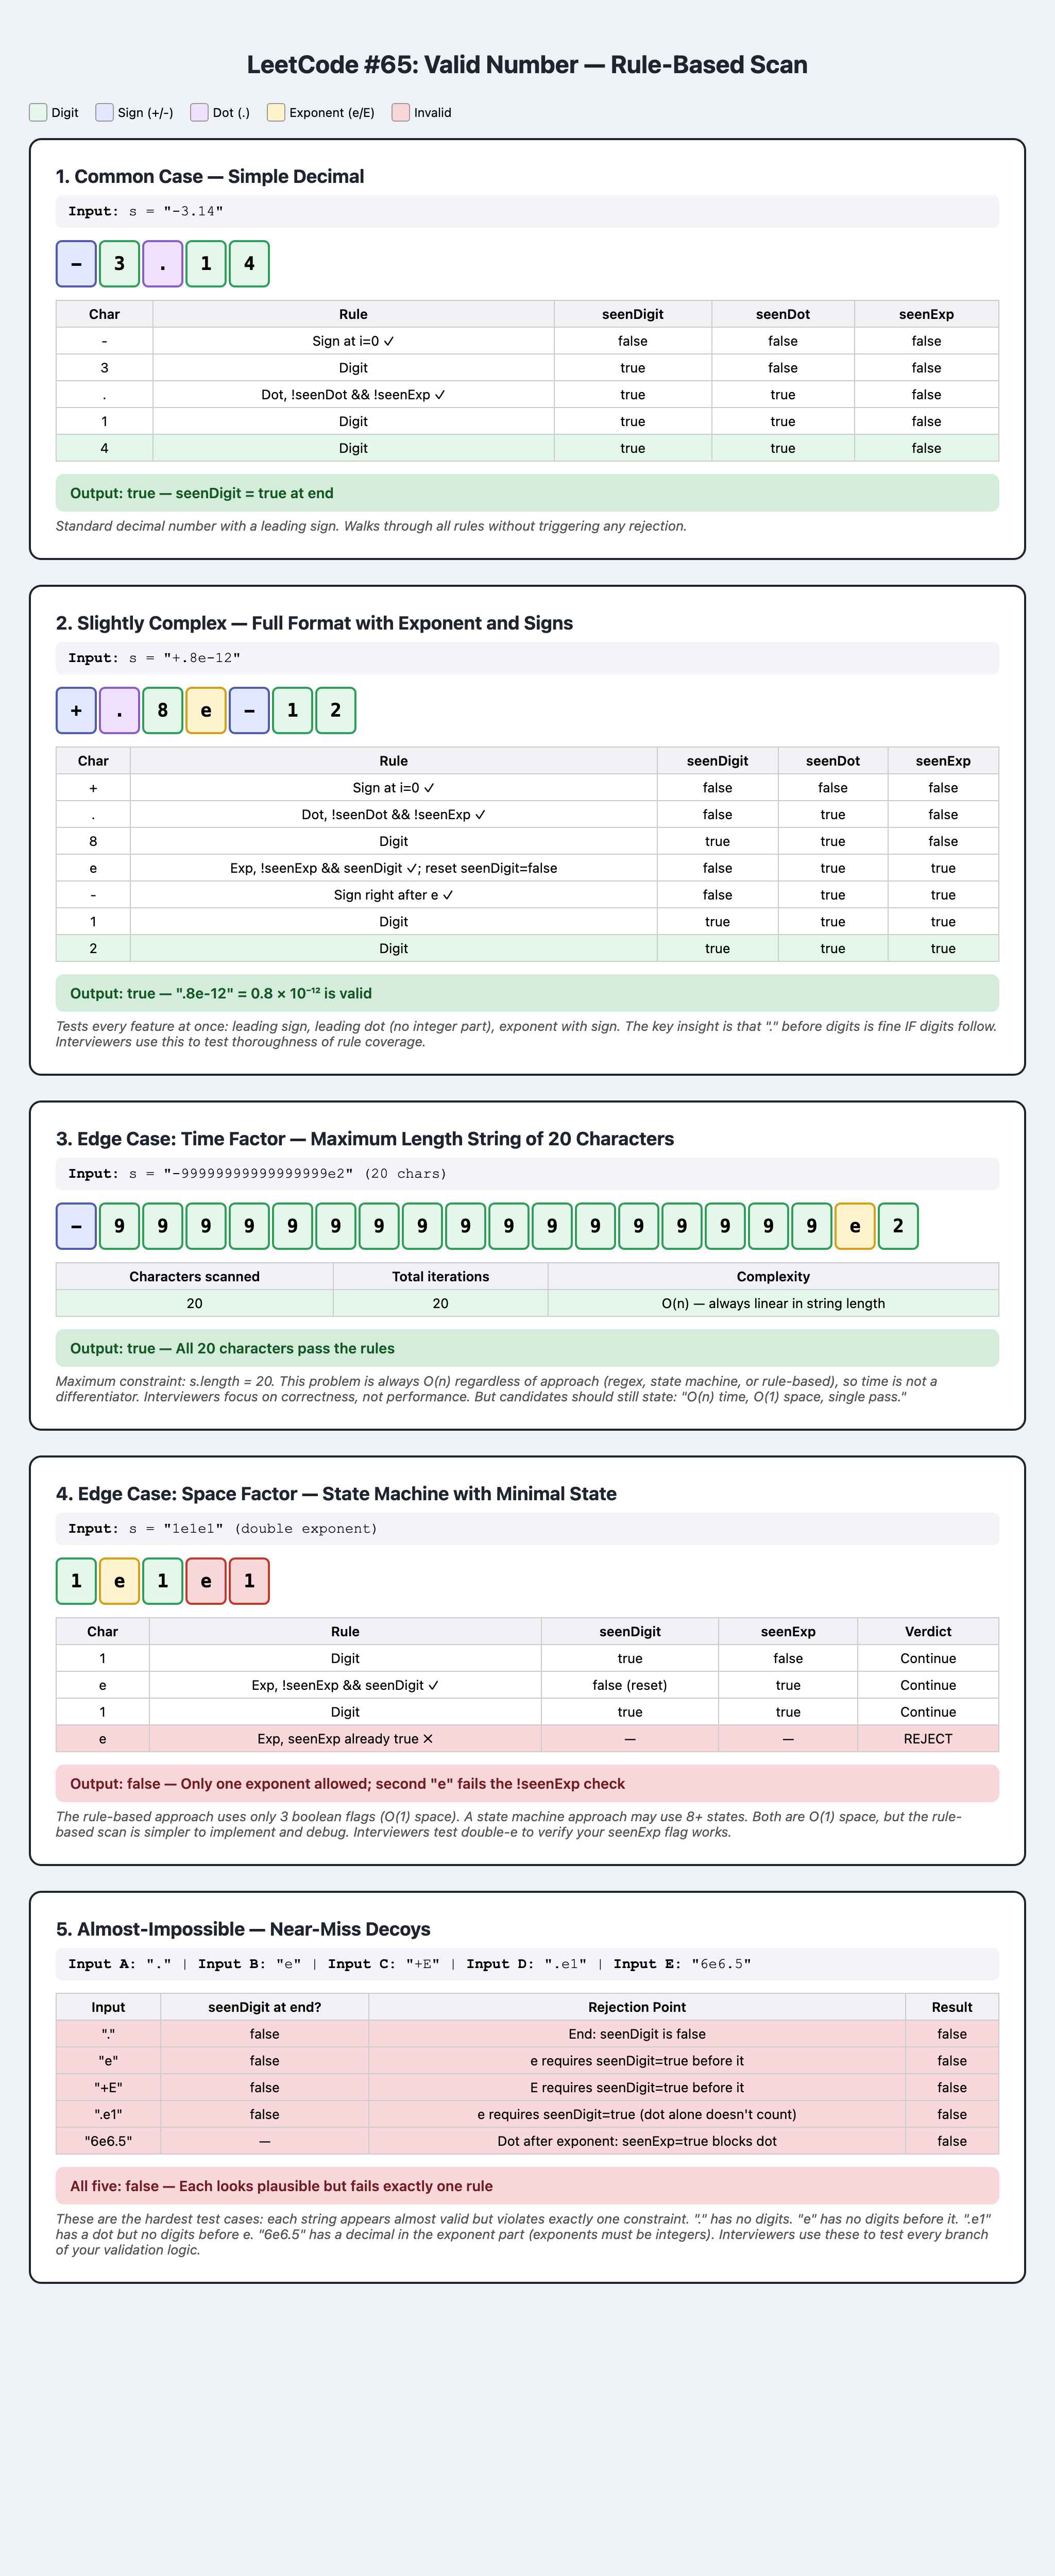